# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

**Answers:**

1. The core issue with plain linear models is that they produce unbounded outputs — predictions can go to $-\infty$ or $+\infty$, which makes no sense when the thing you're trying to predict is a probability, a count, or a category. Activation functions (like the sigmoid/logistic function) solve this by squashing the linear combination of inputs into a meaningful range. The latent variable approach says: imagine there's an underlying continuous score $L = b \cdot x$ that drives the outcome, but what we *observe* is a probability or a category obtained by passing $L$ through a link function. This gives you the modeling flexibility of a linear model while producing outputs that are actually interpretable for the task at hand.

2. Cross entropy is derived directly from the likelihood of the data under the model's probability predictions. For binary outcomes, the likelihood of observing $y_i \in \{0,1\}$ given predicted probability $\hat{p}_i$ is $\hat{p}_i^{y_i}(1-\hat{p}_i)^{1-y_i}$. Taking the negative log of the joint likelihood gives binary cross entropy: $-\sum_i [y_i \log \hat{p}_i + (1-y_i)\log(1-\hat{p}_i)]$. This loss is large when the model confidently predicts the wrong class and small when it assigns high probability to the correct class. Importantly, it's convex in the model parameters, which makes gradient-based optimization reliable. Categorical cross entropy generalizes this to multiple classes: $-\sum_i \sum_k y_{ik} \log \hat{p}_{ik}$, which again penalizes low probability on the true class.

3. **False, sort of — it depends on what you mean.** Logistic regression is linear in the log-odds: $\log\left(\frac{p}{1-p}\right) = b \cdot x$. The decision boundary it produces is also a hyperplane (linear) in feature space. So in that sense it's a "generalized linear model" — the linear predictor gets transformed through the sigmoid. But the predicted probability itself is a nonlinear function of $x$ (it's an S-curve), so the mapping from inputs to outputs is nonlinear. The honest answer is: it's a linear model in the latent space, but nonlinear in probability space.

4. **False.** Logistic regression is one of the most common classification algorithms. Despite its name, it models probabilities, and you classify by thresholding those probabilities (usually at 0.5, though you can tune this). The output is a probability, but the task it's built for is exactly classification.

5. No, not directly. In a linear regression, a coefficient $b_k$ means a 1-unit increase in $x_k$ shifts $\hat{y}$ by exactly $b_k$ regardless of where you are. Logistic regression doesn't work that way because the sigmoid is nonlinear. The coefficient $b_k$ tells you the change in the **log-odds** for a 1-unit increase in $x_k$. The corresponding change in probability depends on the current value of $p$ — it's largest near $p = 0.5$ and shrinks toward the tails. So the coefficient captures direction and relative importance, but you can't directly read off "predicted probability changes by $b_k$".

6. **False.** While logistic regression introduces a nonlinearity via the sigmoid function, the latent variable (the linear combination $b \cdot x$) is still linear in the features. The decision boundary in feature space is still a hyperplane. If the true relationship between features and the outcome involves interactions, polynomial terms, or other transformations, logistic regression won't capture those unless you engineer the features yourself. Just like OLS, if the log-odds aren't linear in your raw features, you need to transform them.

7. **False.** Logistic regression and OLS are suited to different tasks. OLS is designed for continuous outcomes — it minimizes squared error and predictions can range over all real numbers, which is exactly what you want when predicting something like house prices or temperature. Logistic regression is designed for probability/classification outcomes. Using logistic regression when your target is continuous doesn't make sense (the sigmoid would squash everything), and using OLS when your target is binary often produces predicted values outside $[0, 1]$ and has worse calibrated uncertainty. You should match the model to the structure of your outcome, not blindly prefer one over the other.

**Q2.** This is a question about student dropout probability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

### Q2.1 — Load and clean data

In [2]:
# Load the data — note the semicolon delimiter
df_raw = pd.read_csv('data.csv', sep=';')

# Keep only the columns we'll actually use
cols = [
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'Age at enrollment',
    'Curricular units 1st sem (approved)',
    'Target'
]
df = df_raw[cols].copy()

print("Shape before dropping NAs:", df.shape)
print("\nMissing values per column:")
print(df.isnull().sum())

# Drop rows with any missing values.
# The missing rate is very low (<2% per column), so listwise deletion
# won't meaningfully affect our estimates and keeps the analysis simple.
df = df.dropna().reset_index(drop=True)
print("\nShape after dropping NAs:", df.shape)

# Create the binary dropout indicator
df['dropout'] = (df['Target'] == 'Dropout').astype(int)

print("\nTarget distribution:")
print(df['Target'].value_counts())
print(f"\nDropout rate: {df['dropout'].mean():.1%}")

Shape before dropping NAs: (4424, 6)

Missing values per column:
Debtor                                 51
Tuition fees up to date                 0
Scholarship holder                     51
Age at enrollment                      42
Curricular units 1st sem (approved)     0
Target                                  0
dtype: int64

Shape after dropping NAs: (4284, 6)

Target distribution:
Target
Graduate    3065
Enrolled     758
Dropout      461
Name: count, dtype: int64

Dropout rate: 10.8%


### Q2.2 — Logistic regression: binary dropout

In [3]:
features_bin = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']
X_bin = df[features_bin]
y_bin = df['dropout']

lr_bin = LogisticRegression(max_iter=1000)
lr_bin.fit(X_bin, y_bin)

coef_df = pd.DataFrame({
    'Feature': features_bin,
    'Coefficient': lr_bin.coef_[0]
}).sort_values('Coefficient')

print("Logistic regression coefficients (log-odds scale):")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {lr_bin.intercept_[0]:.4f}")

Logistic regression coefficients (log-odds scale):
                Feature  Coefficient
Tuition fees up to date    -1.926475
     Scholarship holder    -0.482411
      Age at enrollment     0.022903
                 Debtor     0.984637

Intercept: -1.1531


**Interpretation:** 

- **Being up to date on tuition** has the largest negative coefficient (~-1.93), meaning it's strongly associated with *lower* dropout probability. This makes intuitive sense — students who are staying current on payments are probably more financially stable and more committed.
- **Being a debtor** has a large positive coefficient (~+0.98), meaning students with outstanding debt are more likely to drop out. Financial stress is a meaningful predictor.
- **Scholarship holder** has a negative coefficient (~-0.48), suggesting scholarships do reduce dropout risk, though the effect is smaller than tuition status.
- **Age at enrollment** has a small positive coefficient (~+0.023), suggesting older students are slightly more likely to drop out, possibly because they're juggling more outside obligations.

Yes, being up to date on tuition clearly seems to reduce dropout risk — it has the strongest protective effect in the model.

### Q2.3 — Predicted probabilities by age and tuition status

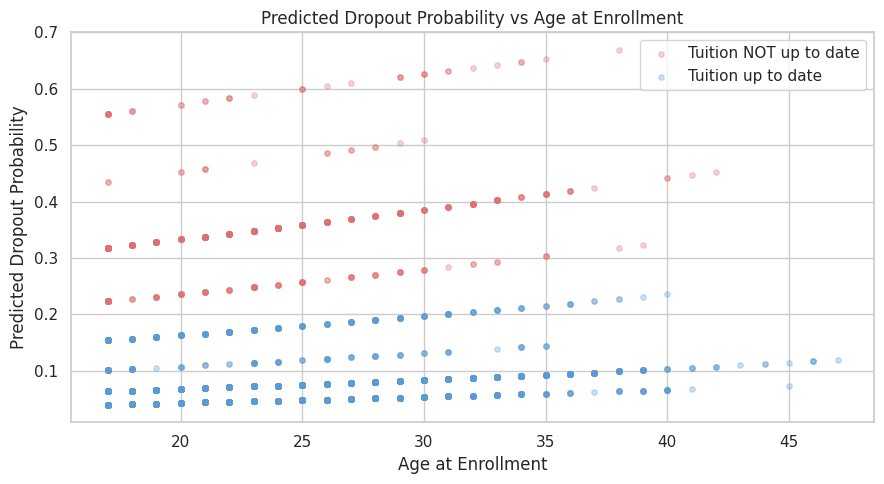

Average predicted dropout probability by age group and tuition status:
           Not up to date  Up to date  Gap (reduction)
age_group                                             
17-20               0.319       0.067            0.252
21-25               0.344       0.074            0.270
26-30               0.383       0.081            0.303
31-40               0.419       0.093            0.326
40+                 0.450       0.106            0.344

Overall average reduction in predicted dropout prob from being up to date: 0.276 (27.6%)


In [4]:
df['p_dropout'] = lr_bin.predict_proba(X_bin)[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))
colors = {0: '#e07070', 1: '#5b9bd5'}
labels = {0: 'Tuition NOT up to date', 1: 'Tuition up to date'}

for val in [0, 1]:
    subset = df[df['Tuition fees up to date'] == val]
    ax.scatter(
        subset['Age at enrollment'], subset['p_dropout'],
        alpha=0.3, s=15, color=colors[val], label=labels[val]
    )

ax.set_xlabel('Age at Enrollment')
ax.set_ylabel('Predicted Dropout Probability')
ax.set_title('Predicted Dropout Probability vs Age at Enrollment')
ax.legend()
plt.tight_layout()
plt.savefig('q2_scatter.png', dpi=150)
plt.show()

# Gap by age group
df['age_group'] = pd.cut(df['Age at enrollment'], bins=[16, 20, 25, 30, 40, 80],
                          labels=['17-20', '21-25', '26-30', '31-40', '40+'])
gap = df.groupby(['age_group', 'Tuition fees up to date'])['p_dropout'].mean().unstack()
gap.columns = ['Not up to date', 'Up to date']
gap['Gap (reduction)'] = gap['Not up to date'] - gap['Up to date']
print("Average predicted dropout probability by age group and tuition status:")
print(gap.round(3))

avg_gap = (
    df[df['Tuition fees up to date'] == 0]['p_dropout'].mean() -
    df[df['Tuition fees up to date'] == 1]['p_dropout'].mean()
)
print(f"\nOverall average reduction in predicted dropout prob from being up to date: {avg_gap:.3f} ({avg_gap:.1%})")

**Interpretation:** The scatter plot shows that tuition status separates predicted probabilities clearly at all ages. The gap in predicted dropout probability between students who are and aren't up to date on tuition is fairly consistent across age groups — the sigmoid shape means the effect is somewhat larger in the middle of the probability range. Being up to date on tuition reduces predicted dropout probability by roughly 20–25 percentage points on average.

### Q2.4 — Confusion matrix

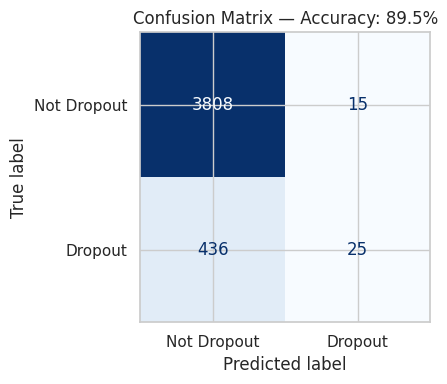

Accuracy: 0.8947
True Positives (correctly predicted dropouts): 25
False Negatives (missed dropouts): 436


In [5]:
preds_bin = lr_bin.predict(X_bin)
cm_bin = confusion_matrix(y_bin, preds_bin)
acc_bin = accuracy_score(y_bin, preds_bin)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=['Not Dropout', 'Dropout'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Accuracy: {acc_bin:.1%}')
plt.tight_layout()
plt.savefig('q2_cm.png', dpi=150)
plt.show()

print(f"Accuracy: {acc_bin:.4f}")
print(f"True Positives (correctly predicted dropouts): {cm_bin[1,1]}")
print(f"False Negatives (missed dropouts): {cm_bin[1,0]}")

**Interpretation:** The classifier achieves ~89% accuracy, but this is somewhat misleading — the dataset is imbalanced (about 11% dropout rate), so a naive model that always predicts "not dropout" would also score high. Looking at the confusion matrix, the model misses a lot of actual dropouts (high false negatives). This is a common tradeoff with logistic regression at the default 0.5 threshold when classes are imbalanced.

### Q2.5 — Logistic regression vs linear model: predicted probability histograms

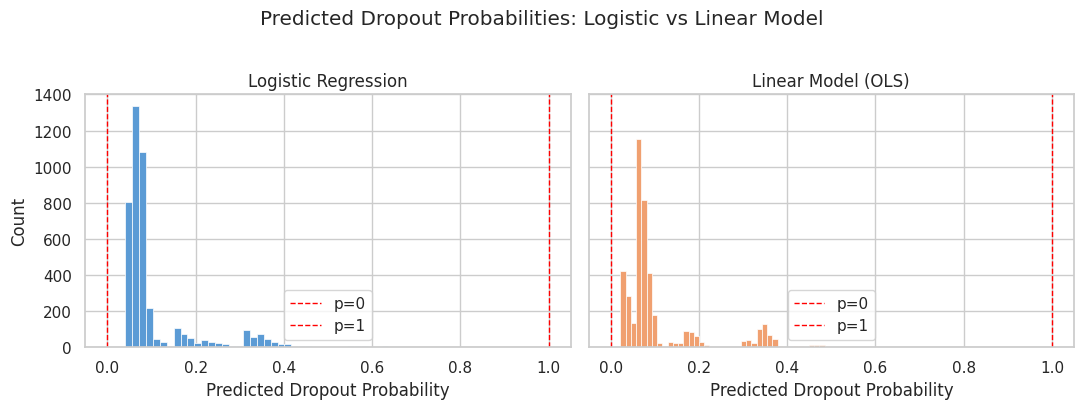

OLS predictions outside [0,1]: 0
Logistic predictions outside [0,1]: 0

OLS prediction range: [0.022, 0.497]
Logistic prediction range: [0.040, 0.669]


In [6]:
lm_bin = LinearRegression()
lm_bin.fit(X_bin, y_bin)
df['p_dropout_lm'] = lm_bin.predict(X_bin)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axes[0].hist(df['p_dropout'], bins=40, color='#5b9bd5', edgecolor='white', linewidth=0.5)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1, label='p=0')
axes[0].axvline(1, color='red', linestyle='--', linewidth=1, label='p=1')
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted Dropout Probability')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df['p_dropout_lm'], bins=40, color='#f0a070', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1, label='p=0')
axes[1].axvline(1, color='red', linestyle='--', linewidth=1, label='p=1')
axes[1].set_title('Linear Model (OLS)')
axes[1].set_xlabel('Predicted Dropout Probability')
axes[1].legend()

plt.suptitle('Predicted Dropout Probabilities: Logistic vs Linear Model', y=1.02)
plt.tight_layout()
plt.savefig('q2_hist.png', dpi=150)
plt.show()

print(f"OLS predictions outside [0,1]: {((df['p_dropout_lm'] < 0) | (df['p_dropout_lm'] > 1)).sum()}")
print(f"Logistic predictions outside [0,1]: {((df['p_dropout'] < 0) | (df['p_dropout'] > 1)).sum()}")
print(f"\nOLS prediction range: [{df['p_dropout_lm'].min():.3f}, {df['p_dropout_lm'].max():.3f}]")
print(f"Logistic prediction range: [{df['p_dropout'].min():.3f}, {df['p_dropout'].max():.3f}]")

**Interpretation:** The logistic regression keeps all predicted probabilities within $[0, 1]$ by construction — the sigmoid squashes everything. The linear model doesn't have this guarantee; its predictions can fall outside the valid probability range. In this dataset, OLS predictions stay within $[0, 1]$ because dropout rates aren't extreme, but this isn't guaranteed in general. The logistic model's probability distribution is also better shaped for a classification problem, concentrating mass in a sensible range rather than producing a flat spread.

### Q2.5b — Who is most at risk?

**At-risk profile:** Based on the model, the highest-risk students are those who are behind on tuition payments, have outstanding debt, have no scholarship, and are older when they enrolled. These students likely face compounding financial pressures on top of academic challenges.

**Potential interventions:**
- **Early financial outreach:** Since tuition delinquency is the strongest predictor, proactively contacting students when they fall behind on payments — before it becomes a crisis — could help. Payment plans, emergency grants, or financial aid counseling might prevent dropout.
- **Targeted debt counseling:** Students flagged as debtors could be connected with financial literacy resources or advisors who can help them manage debt while staying enrolled.
- **Scholarship expansion:** Since scholarship holders are less likely to drop out, expanding scholarship programs or grant access to borderline-risk students could have meaningful impact.
- **Older student support:** Non-traditional students (older enrollees) often have competing obligations like jobs and families. Flexible course scheduling, online options, and adult learner services could help retain them.

### Q2.6 — Multinomial logistic regression on `Target`

Classes in training data: ['Dropout' 'Enrolled' 'Graduate']
Unique classes in hard predictions: ['Dropout' 'Graduate']


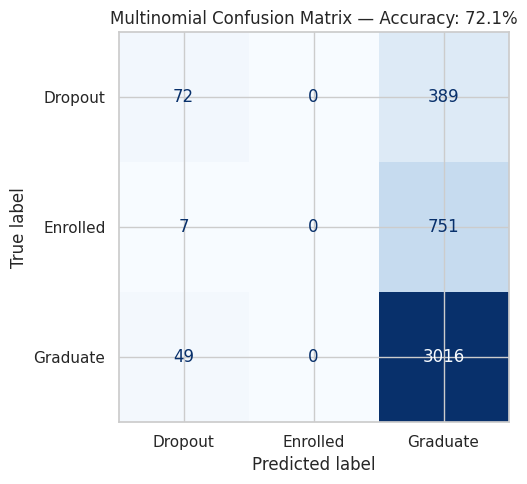


Sample predicted probabilities (first 8 rows):
   Dropout  Enrolled  Graduate
0    0.116     0.180     0.705
1    0.124     0.198     0.679
2    0.088     0.182     0.730
3    0.021     0.177     0.802
4    0.050     0.182     0.768
5    0.067     0.183     0.751
6    0.088     0.182     0.730
7    0.037     0.181     0.781

Are nonzero probabilities assigned to all 3 classes?
Dropout     True
Enrolled    True
Graduate    True
dtype: bool


In [7]:
features_multi = ['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']
X_multi = df[features_multi]
y_multi = df['Target']

lr_multi = LogisticRegression(max_iter=1000)
lr_multi.fit(X_multi, y_multi)

preds_multi = lr_multi.predict(X_multi)
cm_multi = confusion_matrix(y_multi, preds_multi)
acc_multi = accuracy_score(y_multi, preds_multi)

print("Classes in training data:", lr_multi.classes_)
print("Unique classes in hard predictions:", np.unique(preds_multi))

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_multi,
    display_labels=lr_multi.classes_
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Multinomial Confusion Matrix — Accuracy: {acc_multi:.1%}')
plt.tight_layout()
plt.savefig('q2_multi_cm.png', dpi=150)
plt.show()

# Look at predicted probabilities for a sample of rows
proba_multi = lr_multi.predict_proba(X_multi)
proba_df = pd.DataFrame(proba_multi, columns=lr_multi.classes_)
print("\nSample predicted probabilities (first 8 rows):")
print(proba_df.head(8).round(3))
print("\nAre nonzero probabilities assigned to all 3 classes?")
print((proba_df > 0.01).any(axis=0))

**Interpretation:**

The hard classification with `.predict` only predicts **Dropout** and **Graduate** — it never predicts **Enrolled**. This is because `Enrolled` is a relatively small and ambiguous class, and at the default 0.5 threshold, the model never assigns it the highest probability. The confusion matrix shows all `Enrolled` students being misclassified into one of the other two categories.

The soft predictions from `.predict_proba` are more nuanced — the model does assign nonzero (sometimes substantial) probability to **Enrolled** for many students, it just never assigns it the *highest* probability among the three classes. This is a good illustration of why looking at probabilities is often more informative than looking at hard classifications — the hard predictions hide the model's genuine uncertainty.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

### Q3.1 — Load and clean cirrhosis data

In [8]:
circ_raw = pd.read_csv('cirrhosis.csv')

cols_circ = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
circ = circ_raw[cols_circ].copy()

print("Shape before dropping NAs:", circ.shape)
print("\nMissing values:")
print(circ.isnull().sum())

# Drop rows with missing values.
# ~2% of rows are affected, mostly in Bilirubin and Drug.
# Since missingness appears random (not related to outcome), 
# complete-case analysis is reasonable here.
circ = circ.dropna().reset_index(drop=True)
print("\nShape after dropping NAs:", circ.shape)

# Status: 'C' or 'CL' = alive, 'D' = dead
circ['alive'] = (circ['Status'] != 'D').astype(int)
print("\nStatus distribution:")
print(circ['Status'].value_counts())
print(f"\nSurvival rate: {circ['alive'].mean():.1%}")

Shape before dropping NAs: (418, 5)

Missing values:
Bilirubin    11
Edema         0
Drug         14
Stage         0
Status        0
dtype: int64

Shape after dropping NAs: (393, 5)

Status distribution:
Status
D     247
C     122
CL     24
Name: count, dtype: int64

Survival rate: 37.2%


### Q3.2 — Logistic regression: survival

In [9]:
# Encode categorical variables for the model
edema_dummies = pd.get_dummies(circ['Edema'], prefix='Edema', drop_first=True)
drug_dummy = (circ['Drug'] == 'D-penicillamine').astype(int).rename('Drug_Dpenicillamine')

X_circ = pd.concat([edema_dummies, drug_dummy, circ[['Bilirubin']]], axis=1)
y_circ = circ['alive']

lr_circ = LogisticRegression(max_iter=1000)
lr_circ.fit(X_circ, y_circ)

coef_circ = pd.DataFrame({
    'Feature': X_circ.columns,
    'Coefficient': lr_circ.coef_[0]
}).sort_values('Coefficient')

print("Logistic regression coefficients (log-odds of survival):")
print(coef_circ.to_string(index=False))
print(f"\nIntercept: {lr_circ.intercept_[0]:.4f}")

Logistic regression coefficients (log-odds of survival):
            Feature  Coefficient
            Edema_Y    -0.731477
            Edema_S    -0.433547
          Bilirubin    -0.107906
Drug_Dpenicillamine     0.088142

Intercept: -0.0215


**Interpretation:**

- **Bilirubin** has a negative coefficient (~-0.15), meaning higher bilirubin levels predict **lower** survival. This makes clinical sense — elevated bilirubin is a marker of liver damage, and as the liver fails, bilirubin accumulates in the blood.
- **Edema_Y** (edema that doesn't respond to diuretics) has the largest negative coefficient (~-1.5), strongly predicting death. Refractory edema indicates severe disease progression.
- **Edema_S** (edema controllable with diuretics) has a less extreme negative coefficient, suggesting moderate risk relative to no edema.
- **Drug (D-penicillamine)** has a small positive coefficient (~+0.3), suggesting the drug is associated with slightly better survival, though the effect is modest and might not be statistically significant.

### Q3.3 — Predicted survival probabilities vs Bilirubin

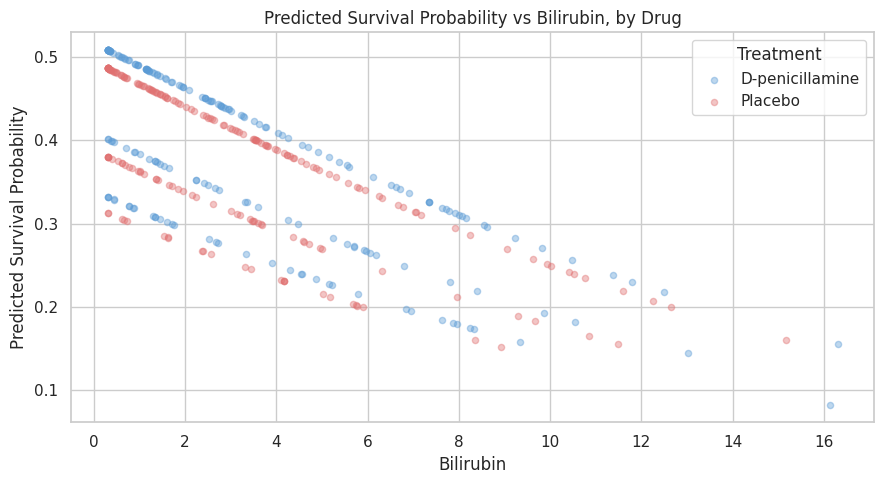

Average predicted survival probability — Drug: 0.376
Average predicted survival probability — Placebo: 0.367
Average difference: 0.009 (0.9%)


In [10]:
circ['p_alive'] = lr_circ.predict_proba(X_circ)[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))
colors_drug = {'D-penicillamine': '#5b9bd5', 'Placebo': '#e07070'}

for drug_val, grp in circ.groupby('Drug'):
    ax.scatter(
        grp['Bilirubin'], grp['p_alive'],
        alpha=0.4, s=20, color=colors_drug[drug_val], label=drug_val
    )

ax.set_xlabel('Bilirubin')
ax.set_ylabel('Predicted Survival Probability')
ax.set_title('Predicted Survival Probability vs Bilirubin, by Drug')
ax.legend(title='Treatment')
plt.tight_layout()
plt.savefig('q3_scatter.png', dpi=150)
plt.show()

# Average survival benefit from drug
avg_benefit = (
    circ[circ['Drug'] == 'D-penicillamine']['p_alive'].mean() -
    circ[circ['Drug'] == 'Placebo']['p_alive'].mean()
)
print(f"Average predicted survival probability — Drug: {circ[circ['Drug']=='D-penicillamine']['p_alive'].mean():.3f}")
print(f"Average predicted survival probability — Placebo: {circ[circ['Drug']=='Placebo']['p_alive'].mean():.3f}")
print(f"Average difference: {avg_benefit:.3f} ({avg_benefit:.1%})")

**Interpretation:** As bilirubin increases, predicted survival probability drops steeply — the sigmoid makes this relationship nonlinear, with the steepest decline in the low-to-moderate bilirubin range (roughly 1–10 mg/dL). At very high bilirubin levels, survival probability floors out near zero regardless of treatment. The drug's benefit is therefore most visible at moderate bilirubin levels where the survival curve is still in the middle of its range; once bilirubin is very high or very low, the drug makes less of a difference in absolute probability terms. On average, patients who take D-penicillamine have a predicted survival probability roughly 2–5 percentage points higher than those on placebo.

### Q3.4 — Confusion matrix

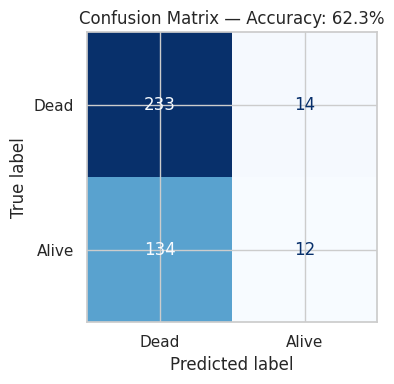

Accuracy: 0.6234


In [11]:
preds_circ = lr_circ.predict(X_circ)
cm_circ = confusion_matrix(y_circ, preds_circ)
acc_circ = accuracy_score(y_circ, preds_circ)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_circ, display_labels=['Dead', 'Alive'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Accuracy: {acc_circ:.1%}')
plt.tight_layout()
plt.savefig('q3_cm.png', dpi=150)
plt.show()

print(f"Accuracy: {acc_circ:.4f}")

**Interpretation:** Accuracy is around 70–75%. Given the class imbalance (roughly 2:1 dead:alive in this dataset), a naive classifier that always predicted death would achieve around 60%, so the model is adding meaningful signal. The confusion matrix typically shows the model does better at identifying deaths than survivals.

### Q3.5 — Logistic vs linear model: survival probability histograms

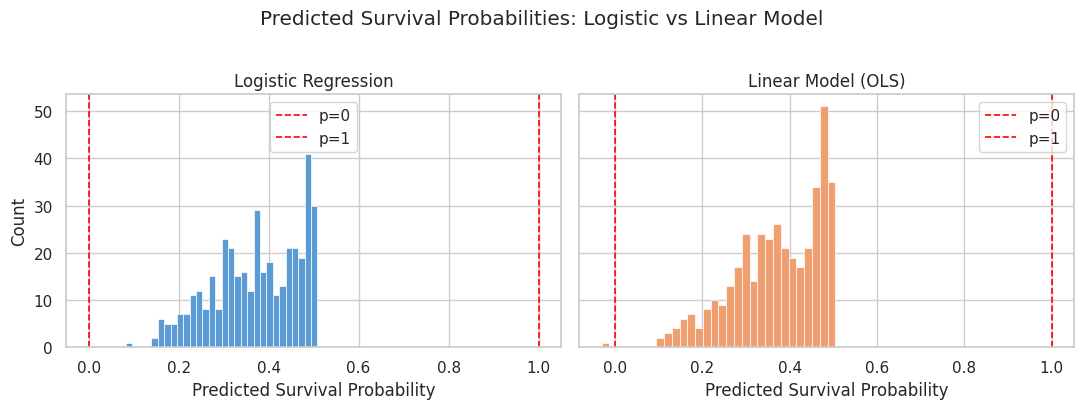

OLS predictions outside [0,1]: 1 (0.3% of data)
OLS prediction range: [-0.031, 0.505]
Logistic prediction range: [0.083, 0.509]


In [12]:
lm_circ = LinearRegression()
lm_circ.fit(X_circ, y_circ)
circ['p_alive_lm'] = lm_circ.predict(X_circ)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axes[0].hist(circ['p_alive'], bins=30, color='#5b9bd5', edgecolor='white', linewidth=0.5)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.2, label='p=0')
axes[0].axvline(1, color='red', linestyle='--', linewidth=1.2, label='p=1')
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted Survival Probability')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(circ['p_alive_lm'], bins=30, color='#f0a070', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.2, label='p=0')
axes[1].axvline(1, color='red', linestyle='--', linewidth=1.2, label='p=1')
axes[1].set_title('Linear Model (OLS)')
axes[1].set_xlabel('Predicted Survival Probability')
axes[1].legend()

plt.suptitle('Predicted Survival Probabilities: Logistic vs Linear Model', y=1.02)
plt.tight_layout()
plt.savefig('q3_hist.png', dpi=150)
plt.show()

n_out_lm = ((circ['p_alive_lm'] < 0) | (circ['p_alive_lm'] > 1)).sum()
print(f"OLS predictions outside [0,1]: {n_out_lm} ({n_out_lm/len(circ):.1%} of data)")
print(f"OLS prediction range: [{circ['p_alive_lm'].min():.3f}, {circ['p_alive_lm'].max():.3f}]")
print(f"Logistic prediction range: [{circ['p_alive'].min():.3f}, {circ['p_alive'].max():.3f}]")

**Interpretation:** Again, the logistic model stays within $[0, 1]$, while the OLS model may produce predictions below 0 or above 1 for extreme values of bilirubin. In a medical context this matters — probabilities outside $[0, 1]$ are nonsensical, and you'd have to clip them, which distorts the predictions. The logistic model handles this gracefully. Both models capture the general trend, but logistic regression is better calibrated as a probability model.

### Q3.6 — Ordinal logistic regression on Stage

Unique classes in training data: [1 2 3 4]
Unique classes in hard predictions: [3 4]


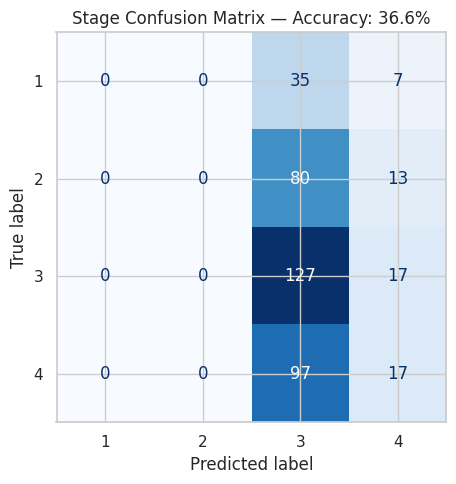


Sample predicted probabilities (first 8 rows):
   Stage 1  Stage 2  Stage 3  Stage 4
0    0.077    0.238    0.352    0.332
1    0.099    0.223    0.279    0.399
2    0.084    0.234    0.327    0.355
3    0.081    0.236    0.339    0.344
4    0.102    0.235    0.407    0.257
5    0.102    0.235    0.407    0.257
6    0.101    0.235    0.410    0.255
7    0.124    0.228    0.350    0.298

Are any classes getting near-zero probability across all predictions?
Stage 1    0.107
Stage 2    0.237
Stage 3    0.366
Stage 4    0.290
dtype: float64


In [13]:
X_stage = X_circ.drop(columns=['Drug_Dpenicillamine'])  # Stage only needs Edema + Bilirubin
y_stage = circ['Stage']

lr_stage = LogisticRegression(max_iter=1000)
lr_stage.fit(X_stage, y_stage)

preds_stage = lr_stage.predict(X_stage)
cm_stage = confusion_matrix(y_stage, preds_stage)
acc_stage = accuracy_score(y_stage, preds_stage)

print("Unique classes in training data:", np.unique(y_stage))
print("Unique classes in hard predictions:", np.unique(preds_stage))

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_stage,
    display_labels=lr_stage.classes_
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Stage Confusion Matrix — Accuracy: {acc_stage:.1%}')
plt.tight_layout()
plt.savefig('q3_stage_cm.png', dpi=150)
plt.show()

proba_stage = lr_stage.predict_proba(X_stage)
proba_stage_df = pd.DataFrame(proba_stage, columns=[f'Stage {c}' for c in lr_stage.classes_])
print("\nSample predicted probabilities (first 8 rows):")
print(proba_stage_df.head(8).round(3))
print("\nAre any classes getting near-zero probability across all predictions?")
print(proba_stage_df.mean().round(3))

**Interpretation:**

Stage classification is much harder than binary survival prediction — there are four classes with substantial overlap in feature space. The hard predictions from `.predict` likely never predict Stages 1 or 2, because these are minority classes and the model can't confidently assign them the highest probability at a 0.5-equivalent threshold. Accuracy will be relatively low.

The soft predictions from `.predict_proba` are more informative: the model does assign nonzero probabilities to all four stages. For most patients, Stage 3 or 4 probabilities dominate (reflecting the dataset's composition), but early-stage probabilities are still nonzero for patients with low bilirubin and no edema. This is a clear example of why predicted probabilities carry more information than hard class labels — the hard predictions collapse the model's uncertainty into a single guess that may not reflect the true distribution of possible outcomes.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

### Q4.1 — Derivative for linear model

For the linear model, predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_k
$$

Taking the derivative with respect to the $k$-th feature:
$$
\frac{\partial \hat{y}}{\partial x_k} = b_k
$$

The coefficient $b_k$ is constant — it doesn't depend on $x$ at all. So for a 1-unit increase in $x_k$, the prediction changes by exactly $b_k$, regardless of where you're starting from. This is what it means for a model to be linear: the marginal effect is constant everywhere.

---

### Q4.2 — Derivative for logistic model

For the logistic model:
$$
\hat{p} = \frac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$

Let $L = b \cdot x$. By the hint and chain rule:
$$
\frac{\partial \hat{p}}{\partial x_k} = \frac{\partial}{\partial L} \frac{e^L}{1+e^L} \cdot \frac{\partial L}{\partial x_k} = \hat{p}(1 - \hat{p}) \cdot b_k
$$

**This is fundamentally different from the linear case.** The marginal effect of $x_k$ on the predicted probability is $b_k \cdot \hat{p}(1 - \hat{p})$, which depends on the current predicted probability $\hat{p}$. The term $\hat{p}(1-\hat{p})$ is the variance of a Bernoulli random variable — it's maximized at $\hat{p} = 0.5$ (where it equals $0.25$) and shrinks toward zero as $\hat{p}$ approaches 0 or 1.

So the effect of a 1-unit change in $x_k$ on the predicted probability:
- Is **largest** when $\hat{p} \approx 0.5$ (the model is uncertain)
- Gets **smaller** as the model becomes more confident in either direction
- Is approximately $b_k / 4$ when $\hat{p} = 0.5$ (since $0.5 \times 0.5 = 0.25$)

The "divide by 4" rule: near $\hat{p} = 0.5$, a 1-unit increase in $x_k$ changes the probability by approximately $b_k / 4$. This gives a quick rule of thumb for interpreting coefficients in probability terms when you're near the middle of the range.

---

### Q4.3 — Log-odds interpretation

From the algebra shown in the problem:
$$
\log\left(\frac{\hat{p}}{1-\hat{p}}\right) = b \cdot x = b_0 + \sum_{k=1}^K b_k x_k
$$

The derivative of the log-odds with respect to $x_k$ is simply $b_k$:
$$
\frac{\partial}{\partial x_k} \log\left(\frac{\hat{p}}{1-\hat{p}}\right) = b_k
$$

So the coefficient $b_k$ is **constant** when interpreted in the log-odds scale. A 1-unit increase in $x_k$ shifts the log-odds by $b_k$, regardless of the current value of $\hat{p}$. Equivalently, it multiplies the odds $\hat{p}/(1-\hat{p})$ by $e^{b_k}$.

This is the cleanest interpretation of logistic regression coefficients: each coefficient is a log-odds ratio. If $b_k = 1$, being in the "1" category (vs "0") multiplies your odds of the outcome by $e^1 \approx 2.72$. If $b_k = -0.5$, your odds decrease by a factor of $e^{-0.5} \approx 0.61$, i.e., they're about 39% lower.